In [1]:
# 如果需要，可取消注释并改成你的路径
import sys
# sys.path.append(r'.')

from importlib import reload
import os
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from lgdo import lh5
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt


/tmp/ipykernel_3230257/3636934470.py:11: DeprecationWarning: lgdo.lh5 has moved to its own package, legend-lh5io. Please replace 'import lgdo.lh5' with 'import lh5'. lgdo.lh5 will be removed in a future release.
  from lgdo import lh5


In [3]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "05"
run_cal = "057"

# bg run 6 days
pnum_phy_bg = "00"
run_phy_bg = "038"
# signal run 13 days
pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]



def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")
        missing_this_run = []
        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")
        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "time_ns": int(m.group(1)),
            "mw": int(m.group(2)),
            "interval": f"{m.group(1)}ns",
            "mw_label": f"mw{m.group(2)}",
            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,
            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,
            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )
    return db
run_db = build_run_db(runs, filepath)


In [4]:
run = 's100ns_mw5'
high_cut_bool_standard = safe_lh5_read(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_High_Side_Cut']
iasy_standard = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['Iasy']

In [6]:
high_cut_bool = np.asarray(high_cut_bool_standard)
iasy = np.asarray(iasy_standard)
is_not_alpha = high_cut_bool & (iasy < 0)
len(is_not_alpha[is_not_alpha==True])
len(is_not_alpha)

12286495

In [13]:
run = 's100ns_mw7'
low_cut_bool = safe_lh5_read(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_Low_Cut']
# high_cut_bool = safe_lh5_read(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_High_Side_Cut']
aoe_field = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_Classifier']
energy_field = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['trapEftp_fix_cal']
is_valid_waveform = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['is_valid_waveform']

low_cut_bool = np.asarray(low_cut_bool)
# high_cut_bool = np.asarray(high_cut_bool)
aoe_field = np.asarray(aoe_field)
energy_field = np.asarray(energy_field)
is_valid_waveform = np.asarray(is_valid_waveform)

E_mask = (energy_field >= 1839) & (energy_field <= 2239)
aoe_mask_valid =E_mask & is_valid_waveform & is_not_alpha
aoe_mask_both_valid = E_mask & low_cut_bool & is_not_alpha & is_valid_waveform
aoe_mask_low_valid = E_mask & low_cut_bool & is_valid_waveform
aoe_valid = aoe_field[aoe_mask_valid]
aoe_both_valid = aoe_field[aoe_mask_both_valid]
aoe_low_valid = aoe_field[aoe_mask_low_valid]

In [8]:
print("sf= ", len(aoe_both_valid)/len(aoe_valid))

sf=  0.0335663607820008


Survival fraction in ROI : 0.034 (1957/57647)


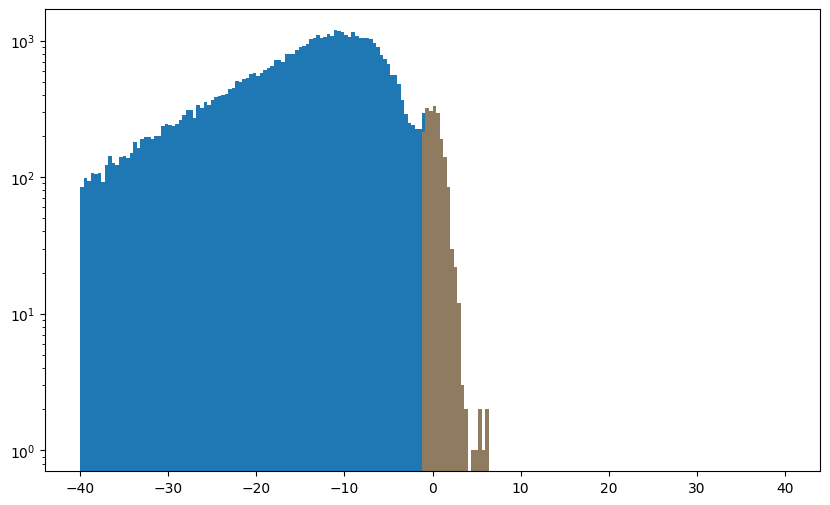

In [14]:
xrange = (-40, 40)
nbins = 200
fig, ax =plt.subplots(figsize=(10, 6))
vals_2, edges_2 = np.histogram(aoe_both_valid, bins=nbins, range=xrange)
ax.set_yscale("log")
vals, edges = np.histogram(aoe_valid, bins=nbins, range=xrange)
ax.stairs(vals, edges, fill=True,alpha=1)
ax.stairs(vals_2, edges_2, fill=True,alpha=0.5)
accepted = len(aoe_both_valid)
sf = accepted/len(aoe_valid)
print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{len(aoe_valid)})")

In [13]:
get_available_fields(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])

['A_max_mw_o_E_Classifier',
 'A_max_mw_o_E_Corrected',
 'A_max_mw_o_E_Double_Sided_Cut',
 'A_max_mw_o_E_High_Side_Cut',
 'A_max_mw_o_E_Low_Cut',
 'A_max_mw_o_E_Timecorr',
 'A_max_mw_o_E_Uncorr',
 'A_max_mw_o_E_fix_Classifier',
 'A_max_mw_o_E_fix_Corrected',
 'A_max_mw_o_E_fix_Double_Sided_Cut',
 'A_max_mw_o_E_fix_High_Side_Cut',
 'A_max_mw_o_E_fix_Low_Cut',
 'A_max_mw_o_E_fix_Timecorr',
 'A_max_mw_o_E_fix_Uncorr',
 'A_max_o_E_Classifier',
 'A_max_o_E_Corrected',
 'A_max_o_E_Double_Sided_Cut',
 'A_max_o_E_High_Side_Cut',
 'A_max_o_E_Low_Cut',
 'A_max_o_E_Timecorr',
 'A_max_o_E_Uncorr',
 'A_max_o_E_fix_Classifier',
 'A_max_o_E_fix_Corrected',
 'A_max_o_E_fix_Double_Sided_Cut',
 'A_max_o_E_fix_High_Side_Cut',
 'A_max_o_E_fix_Low_Cut',
 'A_max_o_E_fix_Timecorr',
 'A_max_o_E_fix_Uncorr',
 'A_max_tri_o_E_Classifier',
 'A_max_tri_o_E_Corrected',
 'A_max_tri_o_E_Double_Sided_Cut',
 'A_max_tri_o_E_High_Side_Cut',
 'A_max_tri_o_E_Low_Cut',
 'A_max_tri_o_E_Timecorr',
 'A_max_tri_o_E_Uncorr',
 'A_

In [17]:
sfs={}
for run in runs:
    low_cut_bool = safe_lh5_read(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_Low_Cut']
    # high_cut_bool = safe_lh5_read(lh5,"ch002/hit",run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_High_Side_Cut']
    aoe_field = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['A_max_mw_o_E_fix_Classifier']
    energy_field = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['trapEftp_fix_cal']
    is_valid_waveform = safe_lh5_read(lh5,'ch002/hit',run_db[run]['phy_signal_pathlist'])['is_valid_waveform']

    low_cut_bool = np.asarray(low_cut_bool)
    # high_cut_bool = np.asarray(high_cut_bool)
    aoe_field = np.asarray(aoe_field)
    energy_field = np.asarray(energy_field)
    is_valid_waveform = np.asarray(is_valid_waveform)

    E_mask = (energy_field >= 1839) & (energy_field <= 2239)
    aoe_mask_valid =E_mask & is_valid_waveform & is_not_alpha
    aoe_mask_both_valid = E_mask & low_cut_bool & is_not_alpha & is_valid_waveform
    aoe_mask_low_valid = E_mask & low_cut_bool & is_valid_waveform
    aoe_valid = aoe_field[aoe_mask_valid]
    aoe_both_valid = aoe_field[aoe_mask_both_valid]
    aoe_low_valid = aoe_field[aoe_mask_low_valid]
    sfs[run] = {
        'total_valid': len(aoe_valid),
        'sf_both_valid': len(aoe_both_valid)/len(aoe_valid),
        'sf_low_valid': len(aoe_low_valid)/len(aoe_valid)
    }
    gc.collect()

In [18]:
import pickle
save_pkl(sfs, 'sfs_r059_ROI_preselection.pkl')

saved to sfs_r059_ROI_preselection.pkl


In [19]:
import numpy as np
from matplotlib import pyplot as plt

def plot_heatmap(sf_results, value, title=None, as_percent=True,cmap='viridis'):
    window = ["60", "100", "200"]
    mw = ["mw7", "mw5", "mw3", "mw1"]

    ROI_sf_matrix = np.full((len(mw), len(window)), np.nan)

    for j, w in enumerate(window):      # columns: window
        for i, m in enumerate(mw):      # rows: mw
            run_name = f"s{w}ns_{m}"

            if run_name not in sf_results:
                print(f"Missing run: {run_name}")
                continue

            ROI_sf_matrix[i, j] = sf_results[run_name][value]

    # Convert 0.093 -> 9.3%, if your stored values are fractions
    if as_percent:
        ROI_sf_matrix = ROI_sf_matrix * 100

    if title is None:
        title = f"{value} heatmap"

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        ROI_sf_matrix,
        vmin=np.nanmin(ROI_sf_matrix),
        vmax=np.nanmax(ROI_sf_matrix),
        cmap=cmap,
        aspect="auto"
    )

    ax.set_title(title)
    ax.set_xlabel("window ns")
    ax.set_ylabel("mw")

    ax.set_xticks(np.arange(len(window)))
    ax.set_xticklabels(window)

    ax.set_yticks(np.arange(len(mw)))
    ax.set_yticklabels(mw)

    for i in range(len(mw)):
        for j in range(len(window)):
            val = ROI_sf_matrix[i, j]

            if np.isnan(val):
                text_str = "nan"
            else:
                text_str = f"{val:.2f}%"

            ax.text(
                j,
                i,
                text_str,
                ha="center",
                va="center",
                color="w" if val < np.nanmax(ROI_sf_matrix) * 0.7 else "black",
                fontsize=9
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Survival fraction [%]")
    plt.tight_layout()
    plt.show()
    return ROI_sf_matrix

In [ ]:
sfs = load_pkl('sfs_r059_ROI_preselection.pkl')

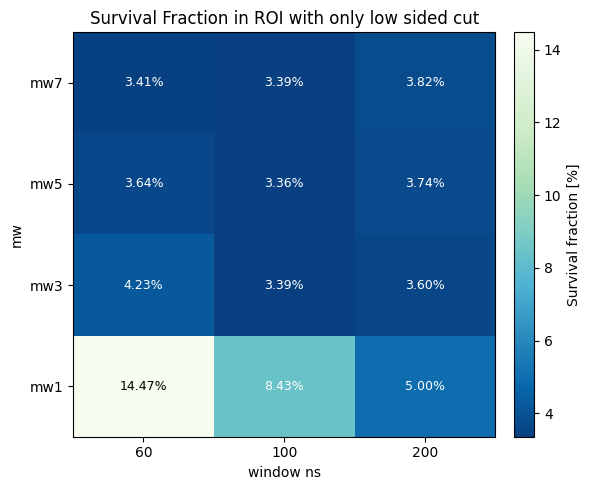

array([[ 3.40520756,  3.39479938,  3.81806512],
       [ 3.64112616,  3.35663608,  3.74000382],
       [ 4.22918799,  3.3861259 ,  3.59775877],
       [14.47256579,  8.43235554,  4.99939286]], shape=(4, 3))

In [28]:
plot_heatmap(sfs,value='sf_both_valid', title='Survival Fraction in ROI with only low sided cut',cmap='GnBu_r', as_percent=True)